# Automatic Short Answer Grading — Mohler Dataset

**Dataset:** Mohler et al. (2011) — 79 questions, ~2,273 student answers, CS domain, scored 0–5 by two graders.

**Approach:** SBERT sentence embeddings + rubric-coverage + lexical features fed into regression models.

## 2. Imports and Configuration

In [ ]:
import os
import numpy as np
import copy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr

# Paths
FOLDER_PATH  = 'data'
DATASET_PATH = os.path.join(FOLDER_PATH, 'dataset.csv')
PREPROCESSED_PATH = os.path.join(FOLDER_PATH, 'dataset_preprocessed.csv')

# Model
SBERT_MODEL = 'all-MiniLM-L6-v2'
BATCH_SIZE = 64
RUBRIC_THRESHOLD = 0.5
MAX_SCORE = 5.0

# Phrases that indicate a blank submission
NO_SUBMISSION_PHRASES = {
    'no submission.', 'no response.', 'no response', 'empty response.', 'empty submission.'
}
STOPWORDS = set(stopwords.words('english'))

FEATURES = [
    'semantic_similarity', # cosine similarity between student and reference answer embeddings
    'rubric_coverage', # fraction of rubric sentences the student answer covers
    'rubric_mean_sim', # mean similarity of rubric coverage
    'rubric_max_sim', # max similarity of rubric coverage
    'keyword_overlap', # keyword overlap between refernce and student answer (Jaccard similarity)
    'length_ratio', # student answer length relative to reference (capped at 3)
]

print(f'Loading SBERT: {SBERT_MODEL}')
MODEL = SentenceTransformer(SBERT_MODEL)

Loading SBERT: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 3. Utility Functions

In [31]:
def tokenize_without_stopwords(text):
    # Lowercase, split, and remove stopwords. Returns a list of content words
    if not text.strip():
        return []
    return [w for w in text.lower().strip().split() if w not in STOPWORDS]


def is_empty_answer(text):
    # Return True if the student submitted nothing meaningful
    return not text.strip() or text.strip().lower() in NO_SUBMISSION_PHRASES

## 4. Data Loading and Cleaning

In [32]:
df = pd.read_csv(DATASET_PATH)

# Rename columns
df = df.rename(columns={'desired_answer': 'reference_answer'})

# Normalize score from 0-5 to 0-1
df['score'] = df['score_avg'] / MAX_SCORE

# Ensure text columns are strings and fill missing values to avoid errors
df['student_answer'] = df['student_answer'].fillna('').astype(str).str.strip()
df['reference_answer'] = df['reference_answer'].fillna('').astype(str)
df['question'] = df['question'].fillna('').astype(str)

# Remove duplicates and rows with missing scores
df = df.dropna(subset=['score']).drop_duplicates().reset_index(drop=True)

print(f'Total samples : {len(df)}')
print(f'Unique questions : {df["question"].nunique()}')
print(f'Score range : {df["score"].min():.2f} – {df["score"].max():.2f}')
print(f'Score mean : {df["score"].mean():.3f}')
print(f'\nScore distribution (normalized):')
print(df['score'].describe().round(3))

Total samples : 2207
Unique questions : 79
Score range : 0.00 – 1.00
Score mean : 0.830

Score distribution (normalized):
count    2207.00
mean        0.83
std         0.22
min         0.00
25%         0.70
50%         0.90
75%         1.00
max         1.00
Name: score, dtype: float64


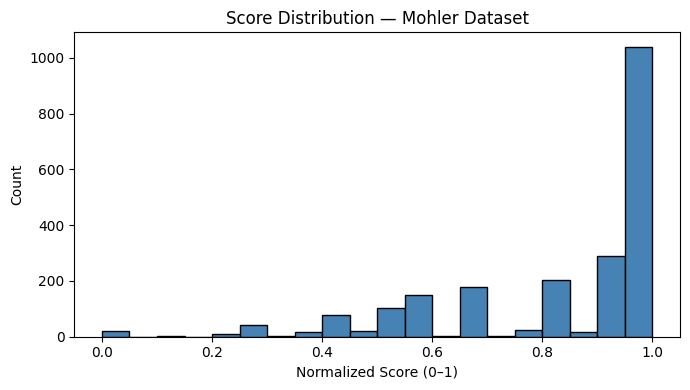

In [33]:
# Score distribution histogram
plt.figure(figsize=(7, 4))
plt.hist(df['score'], bins=20, edgecolor='black', color='steelblue')
plt.xlabel('Normalized Score (0–1)')
plt.ylabel('Count')
plt.title('Score Distribution — Mohler Dataset')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

Three groups of features:
1. **Rubric features** — how well the student answer covers each rubric sentence
2. **Semantic similarity** — overall cosine similarity between student and reference embeddings
3. **Lexical features** — keyword overlap and answer length

In [34]:
def add_rubric_features(df):
    """
    For each student answer, split the reference answer into sentences (those will serve as rubric points as no seperate rubric features) and compute:
      - rubric_coverage : fraction of rubric sentences with similarity >= threshold
      - rubric_mean_sim : mean similarity of all rubrics
      - rubric_max_sim  : max similarity of all rubrics
    """
    coverages = []
    mean_sims = []
    max_sims = []

    # Encode all student answers in one batch for faster processing
    student_embs = MODEL.encode(
        df['student_answer'].tolist(), batch_size=BATCH_SIZE, show_progress_bar=True
    )

    for idx, (_, row) in enumerate(df.iterrows()):
        # Empty submissions get zero for all rubric features
        if is_empty_answer(row['student_answer']):
            coverages.append(0.0)
            mean_sims.append(0.0)
            max_sims.append(0.0)
            continue

        # Split reference answer into individual sentences (rubric points)
        rubric_points = sent_tokenize(row['reference_answer'])
        if not rubric_points:
            coverages.append(0.0)
            mean_sims.append(0.0)
            max_sims.append(0.0)
            continue

        # Compute cosine similarity between the student answer and each rubric point
        rubric_embs = MODEL.encode(rubric_points)
        student_emb = student_embs[idx].reshape(1, -1)
        similarities = cosine_similarity(student_emb, rubric_embs)[0]

        coverages.append(float(np.sum(similarities >= RUBRIC_THRESHOLD) / len(rubric_points)))
        mean_sims.append(float(np.mean(similarities)))
        max_sims.append(float(np.max(similarities)))

    df['rubric_coverage'] = coverages
    df['rubric_mean_sim'] = mean_sims
    df['rubric_max_sim']  = max_sims
    return df


def add_semantic_similarity(df):
    """
    Compute overall cosine similarity between each student answer and its reference answer using batched SBERT encoding.
    Empty submissions are assigned similarity 0.
    """
    reference_embs = MODEL.encode(df['reference_answer'].tolist(), batch_size=BATCH_SIZE)
    student_embs = MODEL.encode(df['student_answer'].tolist(),   batch_size=BATCH_SIZE)

    # Diagonal of the full matrix gives pairwise similarities
    similarities = cosine_similarity(student_embs, reference_embs).diagonal()

    # Override similarity to 0 for empty submissions
    similarities = np.where([is_empty_answer(s) for s in df['student_answer']], 0.0, similarities)
    df['semantic_similarity'] = similarities
    return df


def add_lexical_features(df):
    """
    Compute lexical features that capture surface-level answer quality:
      - keyword_overlap : Jaccard similarity between content words of student and reference
      - length_ratio : student answer length divided by reference answer length, capped at 3x (capping is done to remove extreme outliers who wrote very long answers)
      - is_empty : 1 if the student submitted nothing
    """
    def keyword_overlap(reference, student):
        if not reference.strip() or not student.strip():
            return 0.0
        ref_words = set(tokenize_without_stopwords(reference))
        stu_words = set(tokenize_without_stopwords(student))
        if not ref_words or not stu_words:
            return 0.0
        # Jaccard = intersection / union
        return float(len(ref_words & stu_words) / len(ref_words | stu_words))

    def length_ratio(reference, student):
        ref_len = len(tokenize_without_stopwords(reference))
        stu_len = len(tokenize_without_stopwords(student))
        if ref_len == 0:
            return 0.0
        return min(float(stu_len / ref_len), 3.0)  # cap at 3x to remove outliers

    df['keyword_overlap'] = df.apply(
        lambda r: keyword_overlap(r['reference_answer'], r['student_answer']), axis=1
    )
    df['length_ratio'] = df.apply(
        lambda r: length_ratio(r['reference_answer'], r['student_answer']), axis=1
    )
    df['is_empty'] = df['student_answer'].apply(lambda x: int(is_empty_answer(x)))
    return df

### Preprocessing Pipeline

In [35]:
print('Adding rubric features...')
df = add_rubric_features(df)

print('Adding semantic similarity...')
df = add_semantic_similarity(df)

print('Adding lexical features...')
df = add_lexical_features(df)

# Save file to just load the file in future
df.to_csv(PREPROCESSED_PATH, index=False)
print(f'\nSaved to {PREPROCESSED_PATH}')
print(df[FEATURES].describe().round(3))

Adding rubric features...


Batches:   0%|          | 0/35 [00:00<?, ?it/s]

Adding semantic similarity...
Adding lexical features...

Saved to /content/drive/MyDrive/Mohler/dataset_preprocessed.csv
       semantic_similarity  rubric_coverage  rubric_mean_sim  rubric_max_sim  \
count             2207.000         2207.000         2207.000        2207.000   
mean                 0.562            0.624            0.554           0.565   
std                  0.208            0.473            0.203           0.207   
min                 -0.078            0.000           -0.078          -0.078   
25%                  0.417            0.000            0.417           0.425   
50%                  0.575            1.000            0.565           0.580   
75%                  0.717            1.000            0.703           0.718   
max                  1.000            1.000            1.000           1.000   

       keyword_overlap  length_ratio  
count         2207.000      2207.000  
mean             0.122         1.457  
std              0.153         0.892  
m

## Reload Preprocessed Data

In [36]:
df = pd.read_csv(PREPROCESSED_PATH)
print(f'Loaded {len(df)} rows, {df["question"].nunique()} questions')

Loaded 2207 rows, 79 questions


## 6. Feature Correlation Analysis

We check how strongly each feature relates to the actual score.
Features with higher correlation are more useful for the model. This confirms that our chosen features are meaningful predictors of student performance.

Feature correlations with score:
rubric_mean_sim        0.490
semantic_similarity    0.482
rubric_max_sim         0.482
rubric_coverage        0.403
keyword_overlap        0.346
length_ratio           0.157
Name: score, dtype: float64


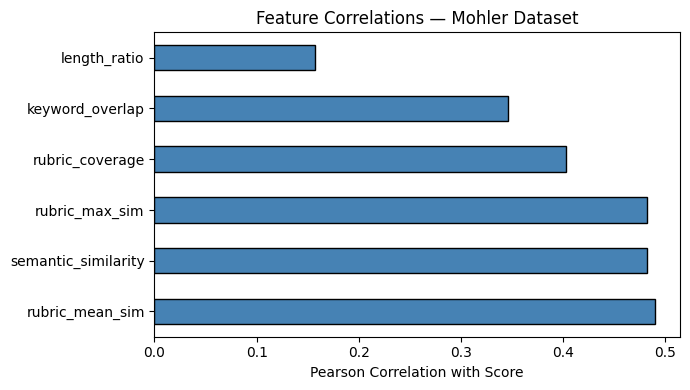

In [37]:
corr = (
    df[FEATURES + ['score']]
    .corr()['score']
    .drop('score')
    .sort_values(ascending=False)
)
print('Feature correlations with score:')
print(corr.round(3))

plt.figure(figsize=(7, 4))
corr.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Pearson Correlation with Score')
plt.title('Feature Correlations — Mohler Dataset')
plt.tight_layout()
plt.show()

## 7. Model Training and Evaluation

**Leave-One-Question-Out Cross-Validation:** For each question, train on all other questions and test on the held-out question. Repeated for all 79 questions. This technique is used to measure generalization to unseen questions in ASAG research.

In [38]:
def loqo_evaluate(df, model_configs, features):
    """
    Leave-One-Question-Out Cross-Validation.
    For each question: train on all other questions and test on the one that was not included.
    This is the standard evaluation for measuring generalization to unseen questions.
    """
    questions = df["question"].unique()
    all_true = []
    model_preds = {name: [] for name, _ in model_configs}

    print(f"Running LOQO-CV over {len(questions)} questions...")

    for i, q in enumerate(questions):
        train_df = df[df["question"] != q]
        test_df  = df[df["question"] == q]

        X_train = train_df[features].values
        y_train = train_df["score"].values
        X_test = test_df[features].values
        y_test = test_df["score"].values

        all_true.extend(y_test.tolist())

        for name, mdl in model_configs:
            m = copy.deepcopy(mdl)

            # Scale features for Ridge as linear models are sensitive to feature scale
            if isinstance(m, Ridge):
                sc = StandardScaler()
                X_tr = sc.fit_transform(X_train)
                X_te = sc.transform(X_test)
            else:
                X_tr, X_te = X_train, X_test

            m.fit(X_tr, y_train)

            # keep predictions in valid range
            preds = np.clip(m.predict(X_te), 0.0, 1.0)
            model_preds[name].extend(preds.tolist())

        if (i + 1) % 10 == 0:
            print(f"  {i+1}/{len(questions)} questions done")

    print("Done.")

    # Compute metrics for each model across all folds
    y_true  = np.array(all_true)
    results = []
    for name, _ in model_configs:
        y_pred = np.array(model_preds[name])
        r, _ = pearsonr(y_true, y_pred)
        sr, _ = spearmanr(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        results.append({
            "Model":      name,
            "Pearson r":  round(r,    4),
            "Spearman r": round(sr,   4),
            "RMSE":       round(rmse, 4),
            "MAE":        round(mae,  4),
        })

    results_df = pd.DataFrame(results).sort_values("Pearson r", ascending=False)
    return results_df, y_true, model_preds


In [39]:
# Ridge: linear regression with regularization — generalizes well to unseen questions
# Random Forest: ensemble of decision trees — included for comparison
MODEL_CONFIGS = [
    ('Ridge (alpha=0.1)',  Ridge(alpha=0.1)),
    ('Ridge (alpha=1.0)',  Ridge(alpha=1.0)),
    ('Ridge (alpha=10.0)', Ridge(alpha=10.0)),
    ('Random Forest',      RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)),
]

results_df, y_true, model_preds = loqo_evaluate(df, MODEL_CONFIGS, FEATURES)

print('\n=== LOQO-CV Results ===')
display(results_df)

Running LOQO-CV over 79 questions...
  10/79 questions done
  20/79 questions done
  30/79 questions done
  40/79 questions done
  50/79 questions done
  60/79 questions done
  70/79 questions done
Done.

=== LOQO-CV Results ===


,Model,Pearson r,Spearman r,RMSE,MAE
2,Ridge (alpha=10.0),0.5136,0.5034,0.1889,0.1434
1,Ridge (alpha=1.0),0.5116,0.5005,0.1892,0.1436
0,Ridge (alpha=0.1),0.5113,0.5002,0.1892,0.1436
3,Random Forest,0.4972,0.5065,0.1916,0.1440


## 8. Visualizations

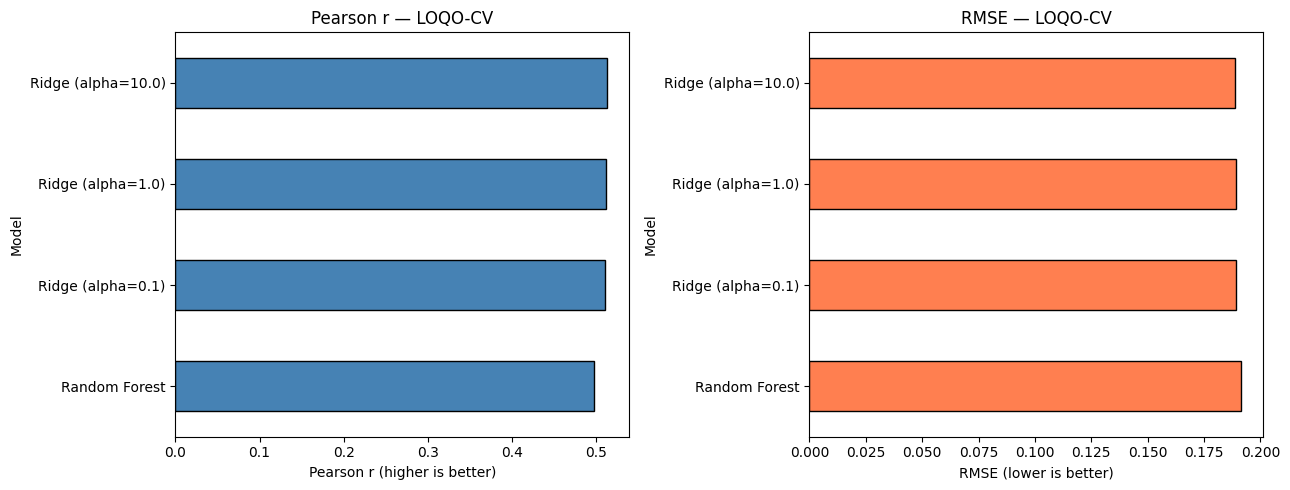

In [40]:
# Model comparison bar charts — Pearson r and RMSE side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

results_df.plot(x='Model', y='Pearson r', kind='barh', ax=axes[0],
                color='steelblue', edgecolor='black', legend=False)
axes[0].set_xlabel('Pearson r (higher is better)')
axes[0].set_title('Pearson r — LOQO-CV')
axes[0].invert_yaxis()

results_df.plot(x='Model', y='RMSE', kind='barh', ax=axes[1],
                color='coral', edgecolor='black', legend=False)
axes[1].set_xlabel('RMSE (lower is better)')
axes[1].set_title('RMSE — LOQO-CV')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

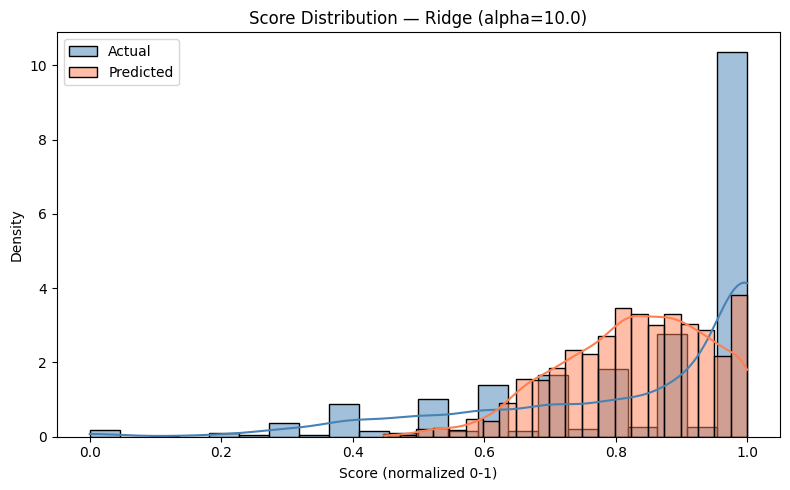

In [41]:
# Distribution plot: actual vs predicted scores for the best model
best_name  = results_df.iloc[0]['Model']
best_preds = np.array(model_preds[best_name])

plt.figure(figsize=(8, 5))
sns.histplot(y_true,     color='steelblue', label='Actual',    kde=True, stat='density', alpha=0.5)
sns.histplot(best_preds, color='coral',     label='Predicted', kde=True, stat='density', alpha=0.5)
plt.xlabel('Score (normalized 0-1)')
plt.ylabel('Density')
plt.title(f'Score Distribution — {best_name}')
plt.legend()
plt.tight_layout()
plt.show()